# New

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import h5py
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim.lr_scheduler import ReduceLROnPlateau
import json
from sklearn.metrics import (classification_report, average_precision_score,
                            confusion_matrix)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

from google.colab import drive
drive.mount('/content/drive')
BASE_DIR = "/content/drive/MyDrive/data/"

Using device: cuda
Mounted at /content/drive


### Data Preprocessing

In [2]:
def load_label_mapping(mapping_path):
    with open(mapping_path, 'r') as f:
        mapping = json.load(f)
    print(f"classes: {mapping['n_classes']}")
    print(f"labels: {list(mapping['label_to_idx'].items())[:]}")
    return mapping

label_mapping = load_label_mapping(BASE_DIR+'label_mapping.json')
n_classes = label_mapping['n_classes']

classes: 15
labels: [('Abies', 0), ('Acer', 1), ('Alnus', 2), ('Betula', 3), ('Cleared', 4), ('Fagus', 5), ('Fraxinus', 6), ('Larix', 7), ('Picea', 8), ('Pinus', 9), ('Populus', 10), ('Prunus', 11), ('Pseudotsuga', 12), ('Quercus', 13), ('Tilia', 14)]


### Dataloader / Augmentation

In [3]:
class H5Dataset(Dataset):
    def __init__(self, h5_path: str):
        self.h5f = h5py.File(h5_path, 'r')
        self.images = self.h5f['images']
        self.labels = self.h5f['labels']
        self.valid_indices = self._filter_nan_samples()
        self.n_samples = len(self.valid_indices)
        print(f"H5Dataset initialized: {h5_path}")
        print(f"Total samples: {len(self.labels)}")
        print(f"Valid samples: {self.n_samples}")

    def _filter_nan_samples(self):
        valid_indices = []
        for idx in range(len(self.h5f['labels'])):
            img = self.images[idx].astype(np.float32)
            input_bands = img[1:3]  # VV, VH
            if not np.isnan(input_bands).any():
                valid_indices.append(idx)
        return valid_indices

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        actual_idx = self.valid_indices[idx]
        img = self.images[actual_idx].astype(np.float32).copy()
        input_bands = img[1:3]  # VV, VH
        label = int(self.labels[actual_idx])

        vv = torch.from_numpy(input_bands[0])  # [H, W]
        vh = torch.from_numpy(input_bands[1])  # [H, W]
        image = torch.stack([vv, vh], dim=0)   # [2, H, W]

        label = torch.tensor(label, dtype=torch.long)
        return image, label

    def get_filename(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['filenames'][actual_idx].decode('utf-8')

    def get_label_name(self, idx):
        actual_idx = self.valid_indices[idx]
        return self.images.file['label_names'][actual_idx].decode('utf-8')

    def close(self):
        if hasattr(self, 'h5f'):
            self.h5f.close()

    def __del__(self):
        self.close()

def create_dataloaders(
    train_h5: str,
    test_h5: str,
    batch_size: int = 128,
    num_workers: int = 4,
    val_ratio: float = 0.1
):
    train_dataset = H5Dataset(train_h5)
    test_dataset = H5Dataset(test_h5)

    original_train_size = len(train_dataset)
    val_size = int(original_train_size * val_ratio)
    train_size = original_train_size - val_size

    torch.manual_seed(42)
    train_indices, val_indices = random_split(
        range(original_train_size),
        [train_size, val_size]
    )

    train_subset = torch.utils.data.Subset(train_dataset, train_indices.indices)
    val_dataset = torch.utils.data.Subset(train_dataset, val_indices.indices)

    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=False
    )

    return train_loader, val_loader, test_loader, train_dataset

In [13]:
batch_size = 64
train_loader, val_loader, test_loader, full_train_dataset = create_dataloaders(
    train_h5=BASE_DIR + 'train_data.h5',
    test_h5=BASE_DIR + 'test_data.h5',
    batch_size=batch_size,
    num_workers=4,
    val_ratio=0.1
)

H5Dataset initialized: /content/drive/MyDrive/data/train_data.h5
Total samples: 45337
Valid samples: 45314
H5Dataset initialized: /content/drive/MyDrive/data/test_data.h5
Total samples: 5044
Valid samples: 5041


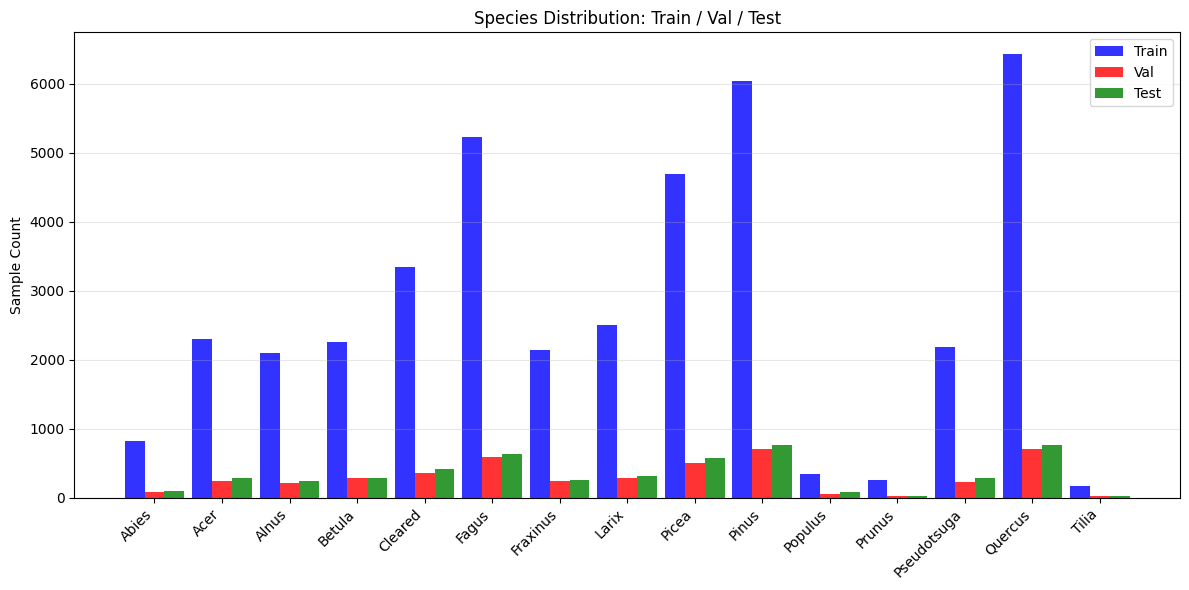

In [6]:
def plot_species_distribution(train_loader, val_loader, test_loader, label_mapping, num_classes):
    """绘制train、val、test set的按树种分布条形图"""
    # 统计每个数据集的类别分布
    def count_labels(loader, num_classes):
        counts = torch.zeros(num_classes, dtype=torch.long)
        for _, labels in loader:
            for label in labels:
                counts[label.item()] += 1
        return counts.numpy()

    train_counts = count_labels(train_loader, num_classes)
    val_counts = count_labels(val_loader, num_classes)
    test_counts = count_labels(test_loader, num_classes)

    # 获取类别名称
    if label_mapping and 'idx_to_label' in label_mapping:
        idx_to_label = label_mapping['idx_to_label']
        if isinstance(list(idx_to_label.keys())[0], str):
            idx_to_label = {int(k): v for k, v in idx_to_label.items()}
        class_names = [idx_to_label.get(i, f'Class_{i}') for i in range(num_classes)]
    else:
        class_names = [f'Class_{i}' for i in range(num_classes)]

    # 设置条形图参数
    n_classes = num_classes
    bar_width = 0.25  # 每个bar的宽度
    group_width = bar_width * 3  # 每组（train+val+test）的总宽度
    group_spacing = 0.1  # 组之间的间距

    # 计算每个组的起始位置
    x_positions = []
    for i in range(n_classes):
        start_pos = i * (group_width + group_spacing)
        x_positions.append([start_pos, start_pos + bar_width, start_pos + 2 * bar_width])

    fig, ax = plt.subplots(figsize=(max(12, n_classes * 0.8), 6))

    colors = ['blue', 'red', 'green']  # train, val, test

    labels = ['Train', 'Val', 'Test']

    for i in range(n_classes):
        values = [train_counts[i], val_counts[i], test_counts[i]]
        for j, (val, color, label) in enumerate(zip(values, colors, labels)):
            ax.bar(x_positions[i][j], val, bar_width, color=color, label=label if i == 0 else '', alpha=0.8)

    ax.set_xticks([pos[1] for pos in x_positions])
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylabel('Sample Count')
    ax.set_title('Species Distribution: Train / Val / Test')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# 绘制train/val/test的树种分布
plot_species_distribution(train_loader, val_loader, test_loader, label_mapping, n_classes)

### UNet++ Model

In [14]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU(),
            nn.Dropout2d(dropout),

            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels, momentum=0.01),
            nn.GELU()
        )

    def forward(self, x):
        return self.conv(x)

In [15]:

class UNetPlusPlus(nn.Module):
    """
    UNet++ for classification tasks(Nested skip connection), adapted for 6×6 small patches
    Input: (B, 2, 6, 6)
    Output: (B, 15)
    Only two pooling layers are possible
    """

    def __init__(self, in_channels=2, num_classes=15, base_channels=32, dropout=0.3):
        super().__init__()

        # configure the number of channels
        nb_filter = [base_channels, base_channels*2, base_channels*4]
        self.pool = nn.MaxPool2d(2, 2)

        self.conv0_0 = ConvBlock(in_channels, nb_filter[0], dropout)
        self.conv1_0 = ConvBlock(nb_filter[0], nb_filter[1], dropout)
        self.conv0_1 = ConvBlock(nb_filter[0] + nb_filter[1], nb_filter[0], dropout)
        self.conv2_0 = ConvBlock(nb_filter[1], nb_filter[2], dropout)
        self.conv1_1 = ConvBlock(nb_filter[1] + nb_filter[2], nb_filter[1], dropout)
        self.conv0_2 = ConvBlock(nb_filter[0]*2 + nb_filter[1], nb_filter[0], dropout)

        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(nb_filter[0] * 2 + nb_filter[2], base_channels * 4),  # 融合3个输出
            nn.BatchNorm1d(base_channels * 4, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(base_channels * 4, base_channels * 2),
            nn.BatchNorm1d(base_channels * 2, momentum=0.01),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),

            nn.Linear(base_channels * 2, num_classes)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # encoder
        x0_0 = self.conv0_0(x)  # (B, 32, 6, 6)
        x1_0 = self.conv1_0(self.pool(x0_0))  # (B, 64, 3, 3)

        # nested nodes
        x0_1 = self.conv0_1(torch.cat([x0_0, F.interpolate(x1_0, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # bottleneck
        x2_0 = self.conv2_0(self.pool(x1_0))  # (B, 128, 1, 1)

        # decoder
        x1_1 = self.conv1_1(torch.cat([x1_0, F.interpolate(x2_0, size=x1_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 64, 3, 3)
        x0_2 = self.conv0_2(torch.cat([x0_0, x0_1, F.interpolate(x1_1, size=x0_0.shape[2:], mode='bilinear', align_corners=True)], 1))  # (B, 32, 6, 6)

        # deep supervision, feature fusion
        out0_1 = self.global_pool(x0_1).flatten(1)  # (B, 32)
        out0_2 = self.global_pool(x0_2).flatten(1)  # (B, 32)
        out_bottleneck = self.global_pool(x2_0).flatten(1)  # (B, 128)

        multi_scale_features = torch.cat([
            out0_1, out0_2, out_bottleneck
        ], dim=1)  # (B, 32+32+128) = (B, 192)

        # clf
        logits = self.classifier(multi_scale_features)

        return logits

### Loss

In [54]:
class PseudoHuberLoss(nn.Module):
    def __init__(self, delta=1.0, alpha=None):
        super(PseudoHuberLoss, self).__init__()
        self.delta = delta

        if alpha is None:
            self.alpha = None
        elif isinstance(alpha, (float, int)):
            self.alpha = torch.tensor([alpha])
        else:
            self.alpha = alpha if isinstance(alpha, torch.Tensor) else torch.tensor(alpha)

    def forward(self, inputs, targets):
        """
        inputs: [B, C] logits
        targets: [B] class indices
        """
        # 先计算交叉熵作为基础误差
        ce_loss = F.cross_entropy(inputs, targets)  # [B]

        # 应用Pseudo-Huber变换: δ² * (√(1 + (x/δ)²) - 1)
        delta_sq = self.delta ** 2
        normalized_loss = ce_loss / self.delta
        ph_loss = delta_sq * (torch.sqrt(1 + normalized_loss ** 2) - 1)

        # 应用类别权重
        if self.alpha is not None:
            if self.alpha.device != inputs.device:
                self.alpha = self.alpha.to(inputs.device)
            alpha_t = self.alpha[targets]
            ph_loss = alpha_t * ph_loss

        # 应用reduction
        return ph_loss.mean()

In [44]:
# class PseudoHuberLoss(nn.Module):
#     """
#     PH(x) = δ² * (√(1 + (x/δ)²) - 1)
#     """
#     def __init__(self, delta=1.0, alpha=None):
#         super().__init__()
#         self.delta = delta
#         self.register_buffer('alpha', torch.tensor(alpha) if not isinstance(alpha, torch.Tensor) else alpha)

#     def forward(self, inputs, targets):
#         ce_loss = F.cross_entropy(inputs, targets, reduction='none')  # [B]

#         # Pseudo-Huber
#         normalized_loss = ce_loss / self.delta
#         ph_loss = self.delta ** 2 * (torch.sqrt(1 + normalized_loss ** 2) - 1)

#         weighted_loss = self.alpha[targets] * ph_loss
#         return weighted_loss.mean()

In [45]:
def compute_class_weights(dataloader, num_classes, method='inverse', beta=0.9999):
    class_counts = torch.zeros(num_classes, dtype=torch.long)

    for _, labels in tqdm(dataloader, desc="Counting labels"):
        for label in labels:
            class_counts[label.item()] += 1

    total_samples = class_counts.sum().item()

    if method == 'inverse':
        weights = 1.0 / class_counts.float()
    elif method == 'balanced':
        weights = total_samples / (num_classes * class_counts.float())
    elif method == 'effective':
        effective_num = 1.0 - torch.pow(beta, class_counts.float())
        weights = (1.0 - beta) / effective_num
    else:
        raise ValueError(f"Unknown method: {method}")

    weights = weights / weights.mean()
    return weights

### Function

In [46]:
def compute_accuracy(pred, target):
    pred_labels = torch.argmax(pred, dim=1)  # [B]
    correct = (pred_labels == target).float()  # [B]
    total = target.size(0)
    accuracy = correct.sum().item() / total if total > 0 else 0.0
    return accuracy

def compute_map(pred, target, num_classes):
    probs = torch.softmax(pred, dim=1).cpu().numpy()  # [B, num_classes]
    target_np = target.cpu().numpy()  # [B]
    if len(target_np) == 0:
        return 0.0
    target_onehot = np.eye(num_classes)[target_np]  # [B, num_classes]
    aps = []
    for i in range(num_classes):
        if target_onehot[:, i].sum() > 0:
            try:
                ap = average_precision_score(target_onehot[:, i], probs[:, i])
                aps.append(ap)
            except:
                continue
    return np.mean(aps) if len(aps) > 0 else 0.0

def collect_layer_gradients(model):
    layer_grads = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_mean_abs = param.grad.abs().mean().item()
            layer_grads[name] = grad_mean_abs
    return layer_grads

In [47]:
def train_classification_paper(model, train_dataset, criterion, optimizer, scheduler, device, epoch, batch_size,
                               steps_per_epoch=50, total_batches=None, return_grads=False):
    """
    Random batch selection. Fixed steps per epoch.
    """
    model.train()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    total_samples = len(train_dataset) # create indices for random batch selection
    pbar = tqdm(range(steps_per_epoch), desc=f"Epoch {epoch+1}")

    for step in pbar:
        indices = torch.randint(0, total_samples, (batch_size,)) # Randomly select batch indices
        batch_data = []
        batch_labels = []

        for idx in indices:
            data, label = train_dataset[idx.item()]
            batch_data.append(data)
            batch_labels.append(label)

        data = torch.stack(batch_data).to(device)
        target = torch.stack(batch_labels).to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        if return_grads and step == steps_per_epoch - 1:
            layer_grads = collect_layer_gradients(model) # for the last batch

        optimizer.step()
        with torch.no_grad():
            acc = compute_accuracy(output, target)

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{acc*100:.1f}%'
        })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    if return_grads:
        return avg_loss, avg_acc, layer_grads
    return avg_loss, avg_acc

In [48]:
def train_one_epoch(model, train_loader, criterion, optimizer, scheduler, device, epoch,
                                return_grads=False):
    """
    Training function using DataLoader (standard training):
    - Iterates through all batches in the loader
    - Uses DataLoader's shuffle and batching
    """
    model.train()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch_idx, (data, target) in enumerate(pbar):
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        if return_grads and batch_idx == len(train_loader) - 1:
            layer_grads = collect_layer_gradients(model)

        optimizer.step()

        with torch.no_grad():
            acc = compute_accuracy(output, target)

        total_loss += loss.item()
        total_acc += acc
        n_batches += 1

        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{acc*100:.1f}%'
        })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    if return_grads:
        return avg_loss, avg_acc, layer_grads
    return avg_loss, avg_acc

In [49]:
def evaluate_classification(model, loader, criterion, device, num_classes):
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")
        for batch_data in pbar:
            data, target = batch_data
            data = data.to(device)
            target = target.to(device)

            # forward
            output = model(data)
            loss = criterion(output, target)

            pred = output.argmax(dim=1)
            correct = (pred == target).sum().item()
            batch_acc = correct / target.size(0)

            total_loss += loss.item() * target.size(0)
            total_correct += correct
            total_samples += target.size(0)

            all_preds.append(output.detach().cpu())
            all_targets.append(target.cpu())

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{batch_acc*100:.1f}%'
            })

    avg_loss = total_loss / total_samples
    avg_acc = total_correct / total_samples

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mAP = compute_map(all_preds, all_targets, num_classes)

    return avg_loss, avg_acc, mAP

### Train

In [39]:
# Compute class weights
class_weights = compute_class_weights(
    train_loader,
    num_classes=n_classes,
    method='inverse',
    beta=0.9
)

Counting labels: 100%|██████████| 638/638 [00:01<00:00, 396.90it/s]


In [55]:
# Initialize UNet++ model
model = UNetPlusPlus(in_channels=2, num_classes=n_classes, base_channels=32, dropout=0.3).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 552,399
Trainable parameters: 552,399


In [56]:
# Pseudo-Huber Loss with class weights
criterion = PseudoHuberLoss(delta=0.1, alpha=class_weights)

# Adam optimizer with low learning rate (as per paper)
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4,  # Low learning rate as specified in paper
    weight_decay=1e-4  # Weight regularization to reduce overfitting
)

In [57]:
# Paper specifications:
# - 5,000 epochs
# - 50 steps per epoch
# - Reduce LR by 10% every 100 epochs when plateau is reached
num_epochs = 5000
# steps_per_epoch = 50

# Learning rate scheduler: reduce by 10% every 100 epochs on plateau
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.9,  # Reduce by 10%
    patience=50,  # Wait 100 epochs before reducing
    min_lr=1e-7
)

best_val_loss = float('inf')
best_val_acc = 0.0
best_val_map = 0.0
patience_counter = 0
early_stop_patience = 100  # Increased for long training

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [], 'val_map': [], 'lr': [],
    'layer_grads': {}
}

print(f"Model: UNet++")
print(f"Epochs: {num_epochs}")
# print(f"Steps per epoch: {steps_per_epoch}")
print(f"Batch size: 128")
print(f"Initial learning rate: {optimizer.param_groups[0]['lr']:.2e}")
print(f"LR reduction: 10% every 100 epochs on plateau")
print(f"Loss: Pseudo-Huber (delta=0.1)")
print(f"Optimizer: Adam with weight decay={optimizer.param_groups[0]['weight_decay']}")

Model: UNet++
Epochs: 5000
Batch size: 128
Initial learning rate: 1.00e-04
LR reduction: 10% every 100 epochs on plateau
Loss: Pseudo-Huber (delta=0.1)
Optimizer: Adam with weight decay=0.0001


In [58]:
for epoch in range(num_epochs):
    # train_loss, train_acc, layer_grads = train_classification_paper(
    #     model, full_train_dataset, criterion, optimizer, scheduler, device, epoch, batch_size,
    #     steps_per_epoch=steps_per_epoch, return_grads=True
    # )

    train_loss, train_acc, layer_grads = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, device, epoch,
        return_grads=True
    )
    val_loss, val_acc, val_map = evaluate_classification(
        model, val_loader, criterion, device, n_classes
    )

    # Update learning rate based on validation loss
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    for layer_name, grad_value in layer_grads.items():
        if layer_name not in history['layer_grads']:
            history['layer_grads'][layer_name] = []
        history['layer_grads'][layer_name].append(grad_value)

    # Print every 10 epochs to reduce output
    if (epoch + 1) % 10 == 0 or epoch < 10:
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val mAP: {val_map:.4f} | LR: {current_lr:.2e}")

    if val_acc > best_val_acc:
        best_val_map = val_map
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_map': val_map,
            'history': history
        }, 'best_unetpp_model.pth')

        if (epoch + 1) % 10 == 0 or epoch < 10:
            print(f" *Best model | mAP: {best_val_map:.4f}, Acc: {best_val_acc*100:.2f}%, Loss: {best_val_loss:.4f}\n")
    else:
        patience_counter += 1
        if (epoch + 1) % 10 == 0 or epoch < 10:
            print(f"Patience: {patience_counter}/{early_stop_patience}\n")

    if patience_counter >= early_stop_patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Evaluating: 100%|██████████| 71/71 [00:00<00:00, 140.20it/s, Loss=0.0541, Acc=15.7%]


Epoch 1/5000
  Train Loss: 0.1047 | Train Acc: 10.47%
  Val Loss:   0.0747 | Val Acc:   19.91% | Val mAP: 0.0997 | LR: 1.00e-04
 *Best model | mAP: 0.0997, Acc: 19.91%, Loss: 0.0747



Evaluating: 100%|██████████| 71/71 [00:00<00:00, 149.29it/s, Loss=0.0524, Acc=17.6%]


Epoch 2/5000
  Train Loss: 0.0849 | Train Acc: 16.42%
  Val Loss:   0.0721 | Val Acc:   22.34% | Val mAP: 0.1004 | LR: 1.00e-04
 *Best model | mAP: 0.1004, Acc: 22.34%, Loss: 0.0721



Evaluating: 100%|██████████| 71/71 [00:00<00:00, 129.89it/s, Loss=0.0514, Acc=17.6%]


...

Epoch 140/5000
  Train Loss: 0.0621 | Train Acc: 32.29%
  Val Loss:   0.0670 | Val Acc:   26.97% | Val mAP: 0.1382 | LR: 1.00e-04
Patience: 84/500



Evaluating: 100%|██████████| 71/71 [00:00<00:00, 141.31it/s, Loss=0.0491, Acc=21.6%]


Epoch 150/5000
  Train Loss: 0.0619 | Train Acc: 32.43%
  Val Loss:   0.0667 | Val Acc:   27.10% | Val mAP: 0.1386 | LR: 1.00e-04
Patience: 94/500



Epoch 152:  81%|████████▏ | 519/638 [00:06<00:01, 83.67it/s, Loss=0.0539, Acc=29.7%]


KeyboardInterrupt: 

### *** Quick Check

In [59]:
print(f"Best Validation Results:")
print(f"  mAP: {best_val_map:.4f}")
print(f"  Accuracy: {best_val_acc*100:.2f}%")
print(f"  Loss: {best_val_loss:.4f}")

Best Validation Results:
  mAP: 0.1442
  Accuracy: 28.43%
  Loss: 0.0660


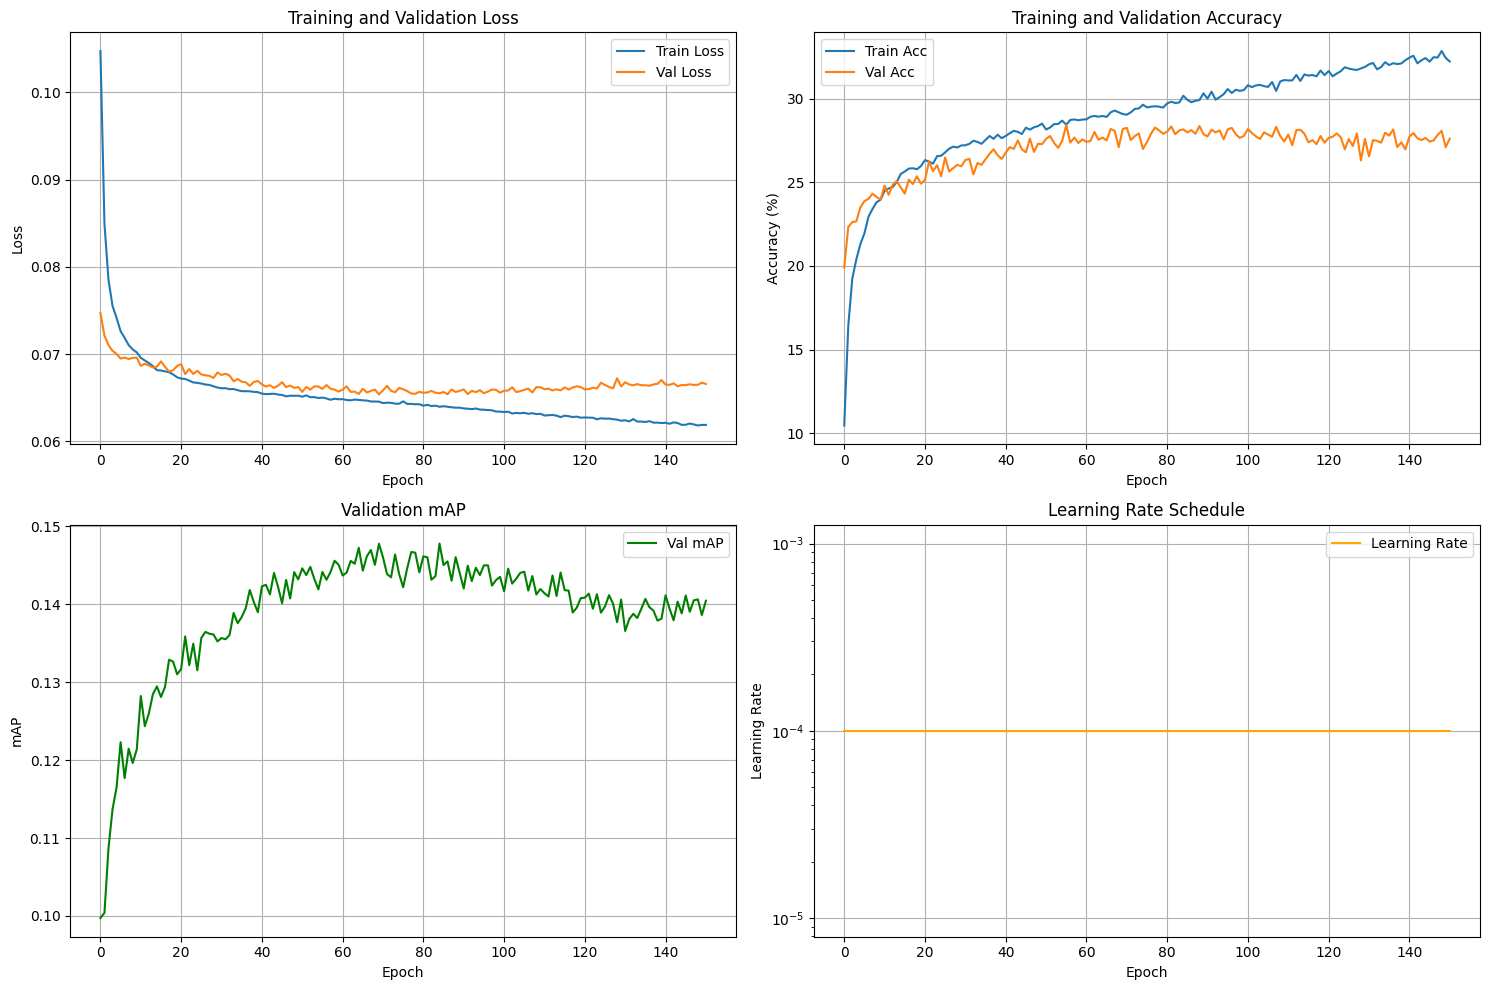

In [60]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    axes[0, 0].plot(history['train_loss'], label='Train Loss')
    axes[0, 0].plot(history['val_loss'], label='Val Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    axes[0, 1].plot([x*100 for x in history['train_acc']], label='Train Acc')
    axes[0, 1].plot([x*100 for x in history['val_acc']], label='Val Acc')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].set_title('Training and Validation Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    axes[1, 0].plot(history['val_map'], label='Val mAP', color='green')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('mAP')
    axes[1, 0].set_title('Validation mAP')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(history['lr'], label='Learning Rate', color='orange')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate Schedule')
    axes[1, 1].set_yscale('log')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()
    plt.savefig('training_history_unetpp.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)

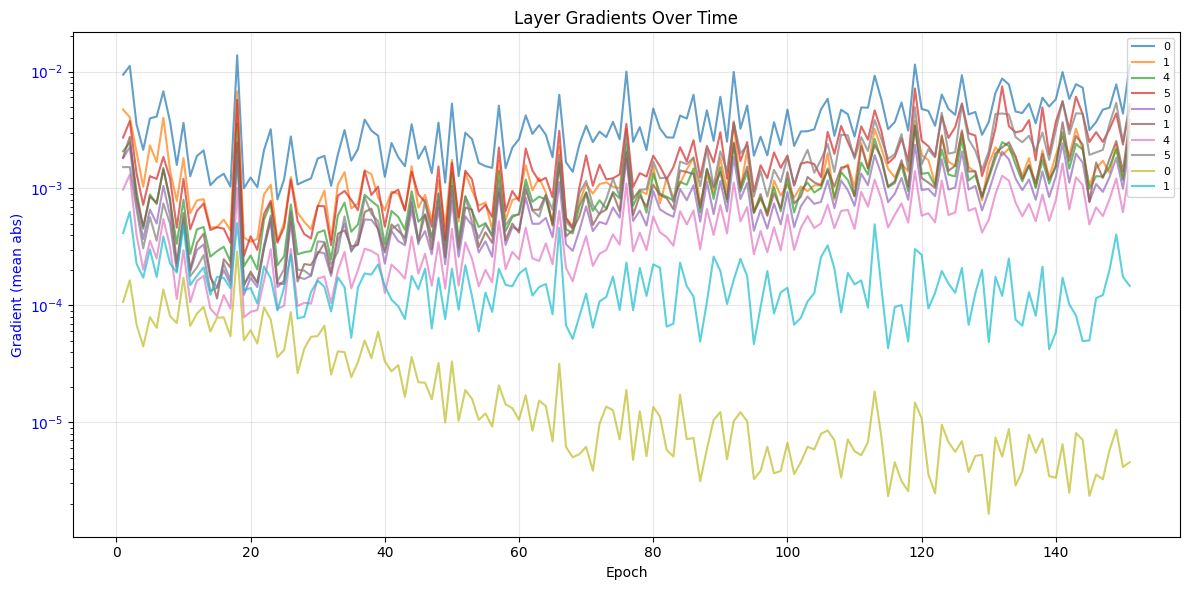

In [66]:

def plot_gradient_and_lr(history):
    if 'layer_grads' not in history or not history['layer_grads']:
        print("No gradient history found. Skipping gradient plot.")
        return

    epochs = range(1, len(history['lr']) + 1)

    fig, ax = plt.subplots(1, 1, figsize=(12, 6))

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gradient (mean abs)', color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title('Layer Gradients Over Time')
    ax.grid(True, alpha=0.3)

    key_layers = []
    for layer_name in history['layer_grads'].keys():
        if 'weight' in layer_name and ('conv' in layer_name or 'classifier' in layer_name or 'stem' in layer_name):
            key_layers.append(layer_name)

    if len(key_layers) > 10:
        key_layers = key_layers[:10]

    colors = plt.cm.tab10(np.linspace(0, 1, len(key_layers)))
    for i, layer_name in enumerate(key_layers):
        if layer_name in history['layer_grads']:
            short_name = layer_name.split('.')[-2] if len(layer_name.split('.')) > 2 else layer_name.split('.')[-1]
            ax.plot(epochs, history['layer_grads'][layer_name],
                    label=short_name, color=colors[i], alpha=0.7, linewidth=1.5)

    ax.legend(loc='upper right', fontsize=8)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

plot_gradient_and_lr(history)

### Test

In [63]:
def evaluate_with_per_class_analysis(model, loader, criterion, device, label_mapping=None):
    """
    Comprehensive evaluation with per-class analysis and confusion matrix
    """
    model.eval()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating on Test Set")
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)

            loss = criterion(output, target)
            acc = compute_accuracy(output, target)

            total_loss += loss.item()
            total_acc += acc
            n_batches += 1

            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{acc*100:.1f}%'
            })

    avg_loss = total_loss / n_batches
    avg_acc = total_acc / n_batches

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Get label names
    if label_mapping and 'idx_to_label' in label_mapping:
        idx_to_label = label_mapping['idx_to_label']
        if isinstance(list(idx_to_label.keys())[0], str):
            idx_to_label = {int(k): v for k, v in idx_to_label.items()}
        target_names = [idx_to_label.get(i, f'Class_{i}') for i in range(len(idx_to_label))]
    else:
        target_names = None

    print(f"Test dataset results:")
    print(f"  Overall Loss: {avg_loss:.4f}")
    print(f"  Overall Accuracy: {avg_acc*100:.2f}%")
    print(f"  Total Samples: {len(all_labels):,}")

    """
    Confusion Matrix
    """
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names if target_names else 'auto',
                yticklabels=target_names if target_names else 'auto',
                cbar_kws={'label': 'Count'})
    plt.title('Confusion Matrix - UNet++', fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    if target_names:
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    """
    sklearn classification report
    """
    print("sklearn classification report:")
    print(classification_report(all_labels, all_preds,
                                target_names=target_names,
                                zero_division=0))

    """
    per-class analysis
    """
    class_acc = cm.diagonal() / cm.sum(axis=1)
    class_counts = cm.sum(axis=1)
    pred_counts = cm.sum(axis=0)

    print(f"{'Class':<20} {'Accuracy':>10} {'True':>8} {'Pred':>8} {'Correct':>8}")

    for i in range(len(class_acc)):
        label_name = target_names[i] if target_names else f'Class_{i}'
        true_count = int(class_counts[i])
        pred_count = int(pred_counts[i])
        correct_count = int(cm[i, i])
        accuracy = class_acc[i] * 100

        print(f"{label_name:<20} {accuracy:>9.2f}% {true_count:>8} {pred_count:>8} {correct_count:>8}")

    print("Summary:")
    print(f"  Overall Accuracy:      {avg_acc*100:.2f}%")
    print(f"  Mean Per-Class Acc:    {class_acc.mean()*100:.2f}%")
    print(f"  Std Per-Class Acc:     {class_acc.std()*100:.2f}%")

    if target_names:
        best_idx = class_acc.argmax()
        worst_idx = class_acc.argmin()
        print(f"\nBest Performing Class:  {target_names[best_idx]:<20} ({class_acc[best_idx]*100:.2f}%)")
        print(f"Worst Performing Class: {target_names[worst_idx]:<20} ({class_acc[worst_idx]*100:.2f}%)")

    return avg_loss, avg_acc, all_preds, all_labels, cm

Loading best model for test evaluation...
Loaded model from epoch 56
  Validation mAP: 0.1442
  Validation Loss: 0.0660
  Validation Acc: 28.43%



Evaluating on Test Set: 100%|██████████| 79/79 [00:00<00:00, 138.82it/s, Loss=0.6960, Acc=26.5%]


Test dataset results:
  Overall Loss: 0.0894
  Overall Accuracy: 26.96%
  Total Samples: 5,041


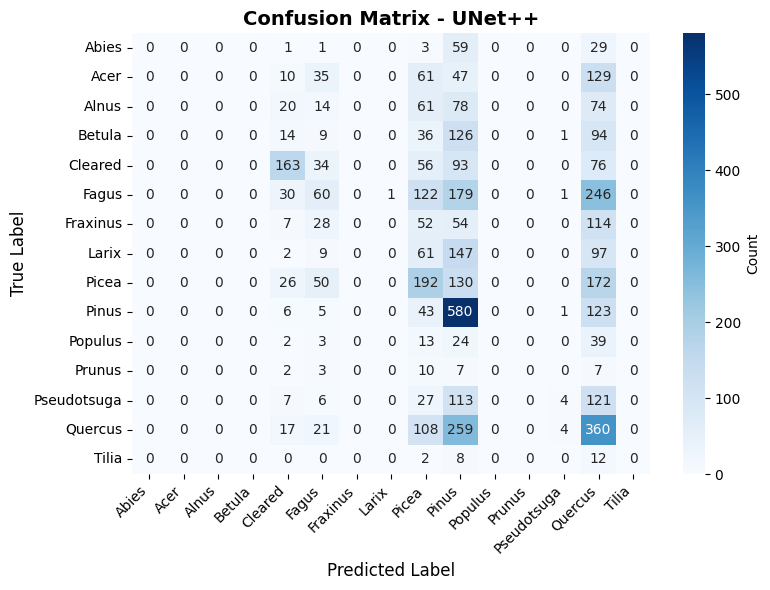

sklearn classification report:
              precision    recall  f1-score   support

       Abies       0.00      0.00      0.00        93
        Acer       0.00      0.00      0.00       282
       Alnus       0.00      0.00      0.00       247
      Betula       0.00      0.00      0.00       280
     Cleared       0.53      0.39      0.45       422
       Fagus       0.22      0.09      0.13       639
    Fraxinus       0.00      0.00      0.00       255
       Larix       0.00      0.00      0.00       316
       Picea       0.23      0.34      0.27       570
       Pinus       0.30      0.77      0.44       758
     Populus       0.00      0.00      0.00        81
      Prunus       0.00      0.00      0.00        29
 Pseudotsuga       0.36      0.01      0.03       278
     Quercus       0.21      0.47      0.29       769
       Tilia       0.00      0.00      0.00        22

    accuracy                           0.27      5041
   macro avg       0.12      0.14      0.11      

In [64]:
# === Load Best Model and Evaluate ===
print("Loading best model for test evaluation...")
checkpoint = torch.load('best_unetpp_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded model from epoch {checkpoint['epoch']+1}")
print(f"  Validation mAP: {checkpoint['val_map']:.4f}")
print(f"  Validation Loss: {checkpoint['val_loss']:.4f}")
print(f"  Validation Acc: {checkpoint['val_acc']*100:.2f}%\n")

test_loss, test_acc, test_preds, test_labels, test_cm = evaluate_with_per_class_analysis(
    model, test_loader, criterion, device, label_mapping=label_mapping
)

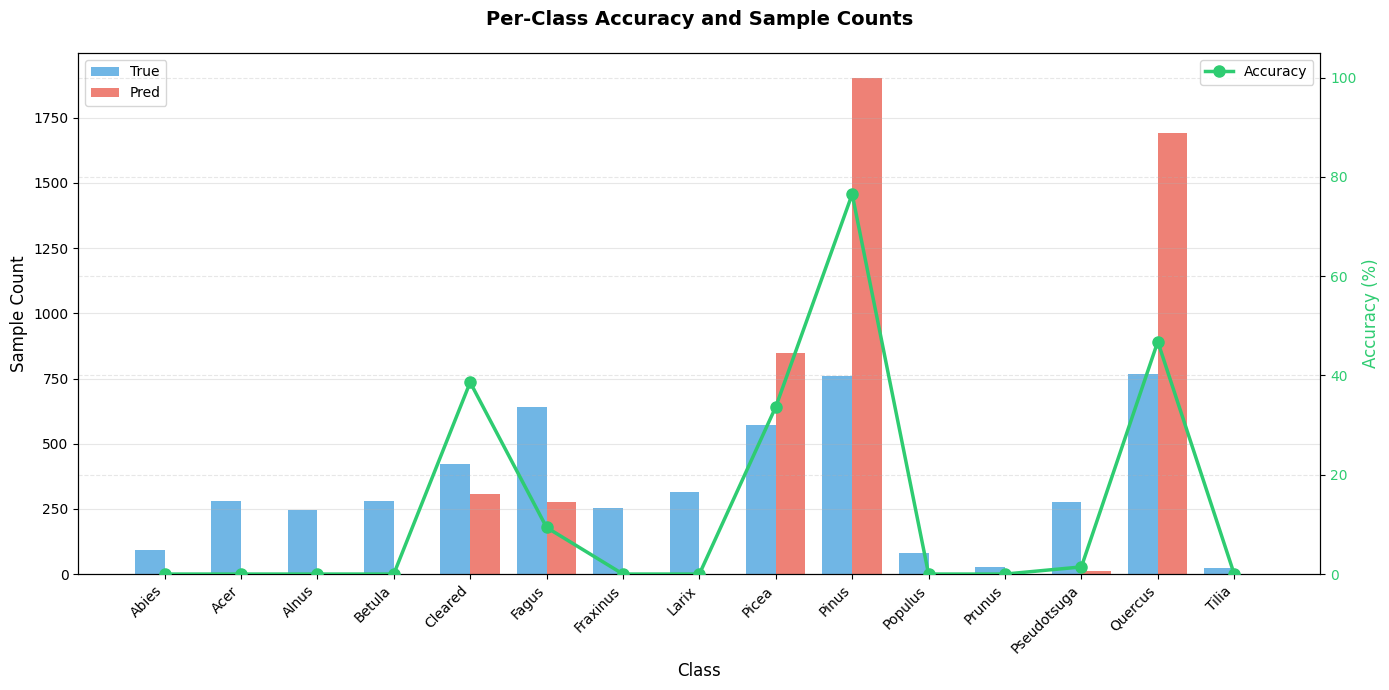

In [65]:

def plot_per_class_accuracy_and_counts(cm, label_mapping=None, num_classes=None):
    """绘制每个类别的accuracy折线图和true/pred条形图"""
    if num_classes is None:
        num_classes = cm.shape[0]

    # 计算每个类别的指标
    class_acc = cm.diagonal() / cm.sum(axis=1)  # 每个类别的accuracy
    true_counts = cm.sum(axis=1)  # 每个类别的真实样本数
    pred_counts = cm.sum(axis=0)  # 每个类别的预测样本数

    # 获取类别名称
    if label_mapping and 'idx_to_label' in label_mapping:
        idx_to_label = label_mapping['idx_to_label']
        if isinstance(list(idx_to_label.keys())[0], str):
            idx_to_label = {int(k): v for k, v in idx_to_label.items()}
        class_names = [idx_to_label.get(i, f'Class_{i}') for i in range(num_classes)]
    else:
        class_names = [f'Class_{i}' for i in range(num_classes)]

    # 设置条形图参数
    bar_width = 0.35  # 每个bar的宽度
    group_width = bar_width * 2  # 每组（true+pred）的总宽度
    group_spacing = 0.2  # 组之间的间距

    # 计算每个组的起始位置
    x_positions = []
    for i in range(num_classes):
        start_pos = i * (group_width + group_spacing)
        x_positions.append([start_pos, start_pos + bar_width])

    # 创建图形和双y轴
    fig, ax1 = plt.subplots(figsize=(max(14, num_classes * 0.9), 7))

    # 绘制条形图（true和pred）
    colors_bar = ['#3498db', '#e74c3c']  # true: 蓝色, pred: 红色
    for i in range(num_classes):
        values = [true_counts[i], pred_counts[i]]
        for j, (val, color) in enumerate(zip(values, colors_bar)):
            ax1.bar(x_positions[i][j], val, bar_width, color=color, alpha=0.7,
                   label='True' if i == 0 and j == 0 else ('Pred' if i == 0 and j == 1 else ''))

    ax1.set_xlabel('Class', fontsize=12)
    ax1.set_ylabel('Sample Count', fontsize=12, color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_xticks([(pos[0] + pos[1]) / 2 for pos in x_positions])  # 在每组中间位置放置标签
    ax1.set_xticklabels(class_names, rotation=45, ha='right')
    ax1.legend(['True', 'Pred'], loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')

    # 创建第二个y轴用于accuracy折线图
    ax2 = ax1.twinx()

    # 计算折线图的x位置（每个类别的中心位置）
    line_x_positions = [(pos[0] + pos[1]) / 2 for pos in x_positions]

    # 绘制accuracy折线图
    ax2.plot(line_x_positions, class_acc * 100, 'o-', color='#2ecc71', linewidth=2.5,
             markersize=8, label='Accuracy', zorder=5)
    ax2.set_ylabel('Accuracy (%)', fontsize=12, color='#2ecc71')
    ax2.tick_params(axis='y', labelcolor='#2ecc71')
    ax2.set_ylim([0, 105])  # accuracy范围0-100%
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3, linestyle='--')

    plt.title('Per-Class Accuracy and Sample Counts', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('per_class_accuracy_and_counts.png', dpi=300, bbox_inches='tight')
    plt.show()

# 绘制每个类别的accuracy和counts
plot_per_class_accuracy_and_counts(test_cm, label_mapping=label_mapping, num_classes=n_classes)

